## Law of large numbers
대수의 법칙(Law of Large Numbers, LLN)은
표본의 크기(시도 횟수)가 커질수록 표본의 평균이 모집단의 진짜 평균(기댓값)에 가까워진다는 확률론의 핵심 정리입니다(제미나이).

Colab. 보여주자. 확인하자.

In [60]:
# _lln_00.py
# law of large numbers, 오차의 크기

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import scipy as sci
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈. 필요한 통계 모듈만.
import statsmodels.api as sm                # 방대한 모델이라 개발자들이 많이 쓰는 모델 묶음.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 소문자 못읽어.
import matplotlib.pyplot as plt


### 파라메타 설정

In [61]:
# 필요한 파라메터 설정
# 표본 크기 지정, beg부터 end까지 stp 간격.
# 1000 부터 1000 간격으로 11000까지. 마지막은 포함하지 않으므로, 총 10개 경우임.
size_beg = 1000
size_end = 21000
size_stp = 1000

# number of iterations, monte carlo simulation given sample size.
n_itr = 2356    # 주어진 표본크기에서 n_itr 만큼 반복.실험.

# 임의변수 생성, 균등분포, 정규분포.
seed = 135678942   # 시드

# 균등분포 시작, 끝, 분산 = (b-a)^2/12 =약 225.33, 표편 약 15.01
# 정규분포라면 mu, sig 적용.
x_beg = 74
x_end = 126
mu = ( x_beg + x_end ) / 2
var = ( x_end - x_beg )**2 / 12
sig = np.sqrt(var)


### 균등분포
 $ X_i \sim U(a, b) $이면(균등분포),  
$$ E(X_i) = { a + b \over 2} , \quad  Var (X_i) = {(b-a )^2 \over 12} $$

$ a=74, b= 126 $일 때, $ \mu=100,\ \sigma^2 =225.3,\ \sigma = 15.01 $.

for large $ n $,
$$ \bar X \approx N( \mu, SE^2) , \quad SE = {\sigma \over \sqrt n } $$.

$ \bar X $의 평균 100, 표준오차 $ 15.01 \over \sqrt n $.

$ n=1000 \to SE =0.474 $,  $ n=10000 \to SE = 0.15 $, ...  

### 주사위 실험 분포
 $ X_i =i \ with\ p={1 \over 6}, \ i=1,\cdots, 6 $. (주사위 실험),  
$$ E(X_i) = 3.5 , \quad  Var (X_i) = {35 \over 12}\approx 2.92 $$

$ \mu= 3.5,\ \sigma^2 =2.92,\ \sigma = 1.71 $.

for large $ n $,
$$ \bar X \approx N( \mu, SE^2) , \quad SE = {\sigma \over \sqrt n } $$.

$ \bar X $의 평균 3.5, 표준오차 $ 1.71 \over \sqrt n $.

$ n=1000 \to SE =0.054 $,  $ n=10000 \to SE = 0.017 $, ...  

## 반복실험
n 크기 마다 수 천 번 반복 --> 분포 히스토그램
n 크기 늘려서 동일 실험 반복 --> 히스토그램 반복 생성


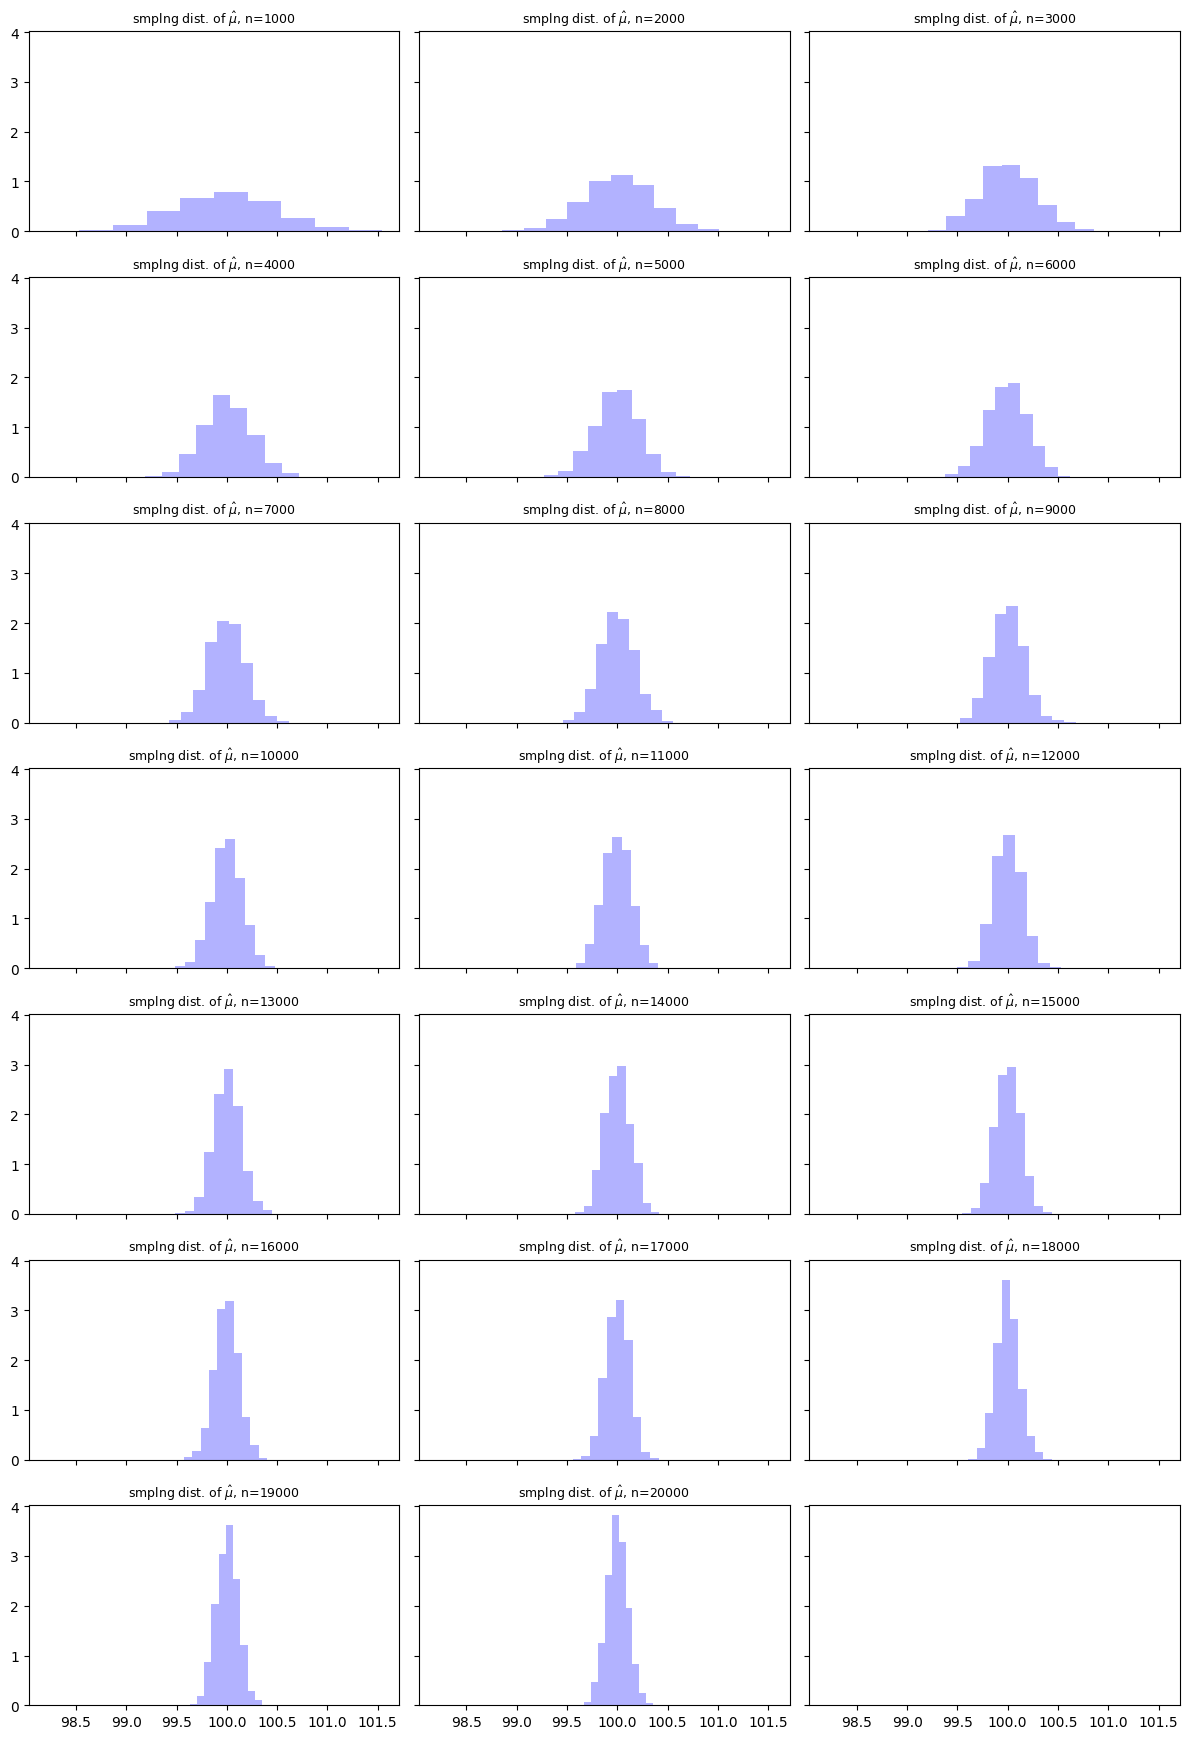

In [62]:
# 1. 데이터 준비. 읽기. 생성. random number
rng = np.random.default_rng(seed)
smpls = np.arange(size_beg, size_end, size_stp) # 다양한 표본 크기 트라이...

# 2. 그림(서브플롯) 생성 준비.
sub_n = len(smpls) # 플롯 갯수, 시도하는 표본 크기
sub_c = 3  # 열 갯수
sub_r = int(np.ceil(sub_n/sub_c))   # 행 갯수
fig_s = 12            # 전체 그림 가로
box_w = fig_s/sub_c            # 플롯 가로 3
box_h = box_w*(10/16)          # 플롯 세로, 황긍비 스타일

fig, axes = plt.subplots(nrows= sub_r, ncols= sub_c, figsize=(sub_c*box_w, sub_r*box_h), sharex=True, sharey=True)

# 2.1. 2차원 배열인 axes를 1차원(10개)으로 평평하게 폄.
axes = axes.flatten()

# 1.1. 계산 결과를 담을 리스트. 여기에 표본 평균을 담음.
## 표본 크기에서 모의실험 결과 정리. 표본크기, 평균의 평균, 평균의 표준편차
muhat_rslt = []

# 3. 반복문 실행. 이건 일종의 따블 반복문. k, i,
for sub_i, k in enumerate(smpls) : # 다양한 표본 크기 트라이... np.arange(size_beg, size_end, size_stp)):
    # 서브플롯 순서를 sub_i로 받음.
    # smpls = np.arange(size_beg, size_end, size_stp):
    # a에서 b까지 c씩 증가, 끝은 포함하지 않음. 인텍스 k. 매번 smpls 원소 하나를 k로 받는데, n_smpl로 명칭 변경..
    n_smpl = k

    # 각 서브플롯 선택, enumerate 인덱스 sub_i로 받음. 이것은 0,1,... 이런 인덱스임.
    ax = axes[sub_i]

    # 표본 크기 고정. 평균 추정치 묶음 그릇(리스트) 지정. 234회 => 평균치 234개, n_itr 개
    muhat = []

    # 반복문(인덱스 k, 지정된 표본 크기) 내 반복문(인덱스 i)임.
    for i in np.arange(0, n_itr, 1) :  # 0에서 itr까지 1씩 증가
        #x = rng.normal(loc=mu, scale=sig, size=n_smpl)  # obs tbg
        x = rng.uniform(x_beg, x_end, n_smpl)
        muhat.append(np.mean(x))     # 매회 muhat 계산, 반복할 때 추가, append.

    # 서브플롯 생성(반복문 i 바깥, 반복문 k 내부)
    ax.hist(muhat,
            color="blue",
            density='True',
            alpha=0.3
            )      # n_smpl = 1000, n_itr = 2345 반복시 평균 분포 히스토그램(상자그림 가능)
    ax.set_title(f'smplng dist. of $ \\hat \\mu $, n={k}', fontsize=9) # n_smpl 별 서브플롯

    # 서브 계산(인덱스 k): 표본 크기, 평균의 평균, 평균의 표준오차, 통계치 계속 쌓아 올림.
    muhat_mean = np.mean(muhat)     # 표본 크기 고정, n_itr 반복 평균치의 평균. for i 바깥임. 끝난 후.
    muhat_std = np.std(muhat, ddof=1)

    # 서브 계산(인덱스 k): 통계치(평균의 평균&표준오차) 계속 쌓아 올림.
    muhat_rslt.append( [n_smpl, muhat_mean, muhat_std] )  # 표본 크기마다 계산된 통계치 쌓음.
                                                             # n의 크기와 평균의 평균, 평균의 표준편차
                                                             # 최종 산출물, 관심 대상.
    # 여기까지 인덱스 k 진행중. 인덱스 i 벗어남.
# 인텍스 k 벗어남. 최종 결과들.
plt.tight_layout()
plt.show()


### 그래프에서 확인할 수 있는 것
표본 평균이 분포를 보인다는 것.

분포의 중심은 여전하지만, 펼침은 좁아진다.

표본 평균은 모 평균으로 수렴한다.

$$ \bar X, \hat \mu \to \mu $$

### 표본 크기와 오차(표준오차)

In [63]:

# 5. 서브 계산치 인쇄.
# 표본 크기가 증가하면 표본평균의 표준오차는 0으로, 즉, 모평균에 접근, 확인.
muhat_rslt = np.array(muhat_rslt)   # numpy 배열로 전환.
np.set_printoptions(suppress=True, precision=4)
print(muhat_rslt)                   # 포맷, 배열 형식 차이 확인...
# print(f"{muhat_rslt:f}")  # 이것은 배열이나 numpy array에서 안됨, 숫자 1개일 때 적용.
n_obs = muhat_rslt[:,0].reshape(-1,1)
sig2_here = (x_end-x_beg)**2 / 12      # 균등분포의 분산
se_thry = np.sqrt( sig2_here / n_obs )
print("Theoretical SE of muhat: ")
print(  se_thry  )

[[ 1000.        99.9839     0.4839]
 [ 2000.       100.0103     0.3314]
 [ 3000.       100.0038     0.274 ]
 [ 4000.       100.0006     0.2386]
 [ 5000.        99.9982     0.2141]
 [ 6000.        99.9965     0.1995]
 [ 7000.       100.0005     0.1801]
 [ 8000.       100.0004     0.1721]
 [ 9000.        99.9972     0.1634]
 [10000.        99.9991     0.1499]
 [11000.        99.9964     0.1401]
 [12000.       100.001      0.1383]
 [13000.       100.0032     0.1339]
 [14000.       100.0034     0.1267]
 [15000.       100.001      0.124 ]
 [16000.        99.9964     0.1205]
 [17000.       100.0034     0.1147]
 [18000.       100.         0.1135]
 [19000.       100.0034     0.109 ]
 [20000.        99.9994     0.1053]]
Theoretical SE of muhat: 
[[0.4747]
 [0.3357]
 [0.2741]
 [0.2373]
 [0.2123]
 [0.1938]
 [0.1794]
 [0.1678]
 [0.1582]
 [0.1501]
 [0.1431]
 [0.137 ]
 [0.1317]
 [0.1269]
 [0.1226]
 [0.1187]
 [0.1151]
 [0.1119]
 [0.1089]
 [0.1061]]


### 표본 크기가 증가하면, 표준오차(제 3열)는 감소한다.
극단적으로 0에 접근할 것이다.

즉,
표본평균은 중심(모평균)에 집중, 수렴할 것이다.

### 발견: 이론적 표준오차 크기와 매우 유사하다.
반복실험으로 추측한 값이 이론 값과 거의 동일하다.

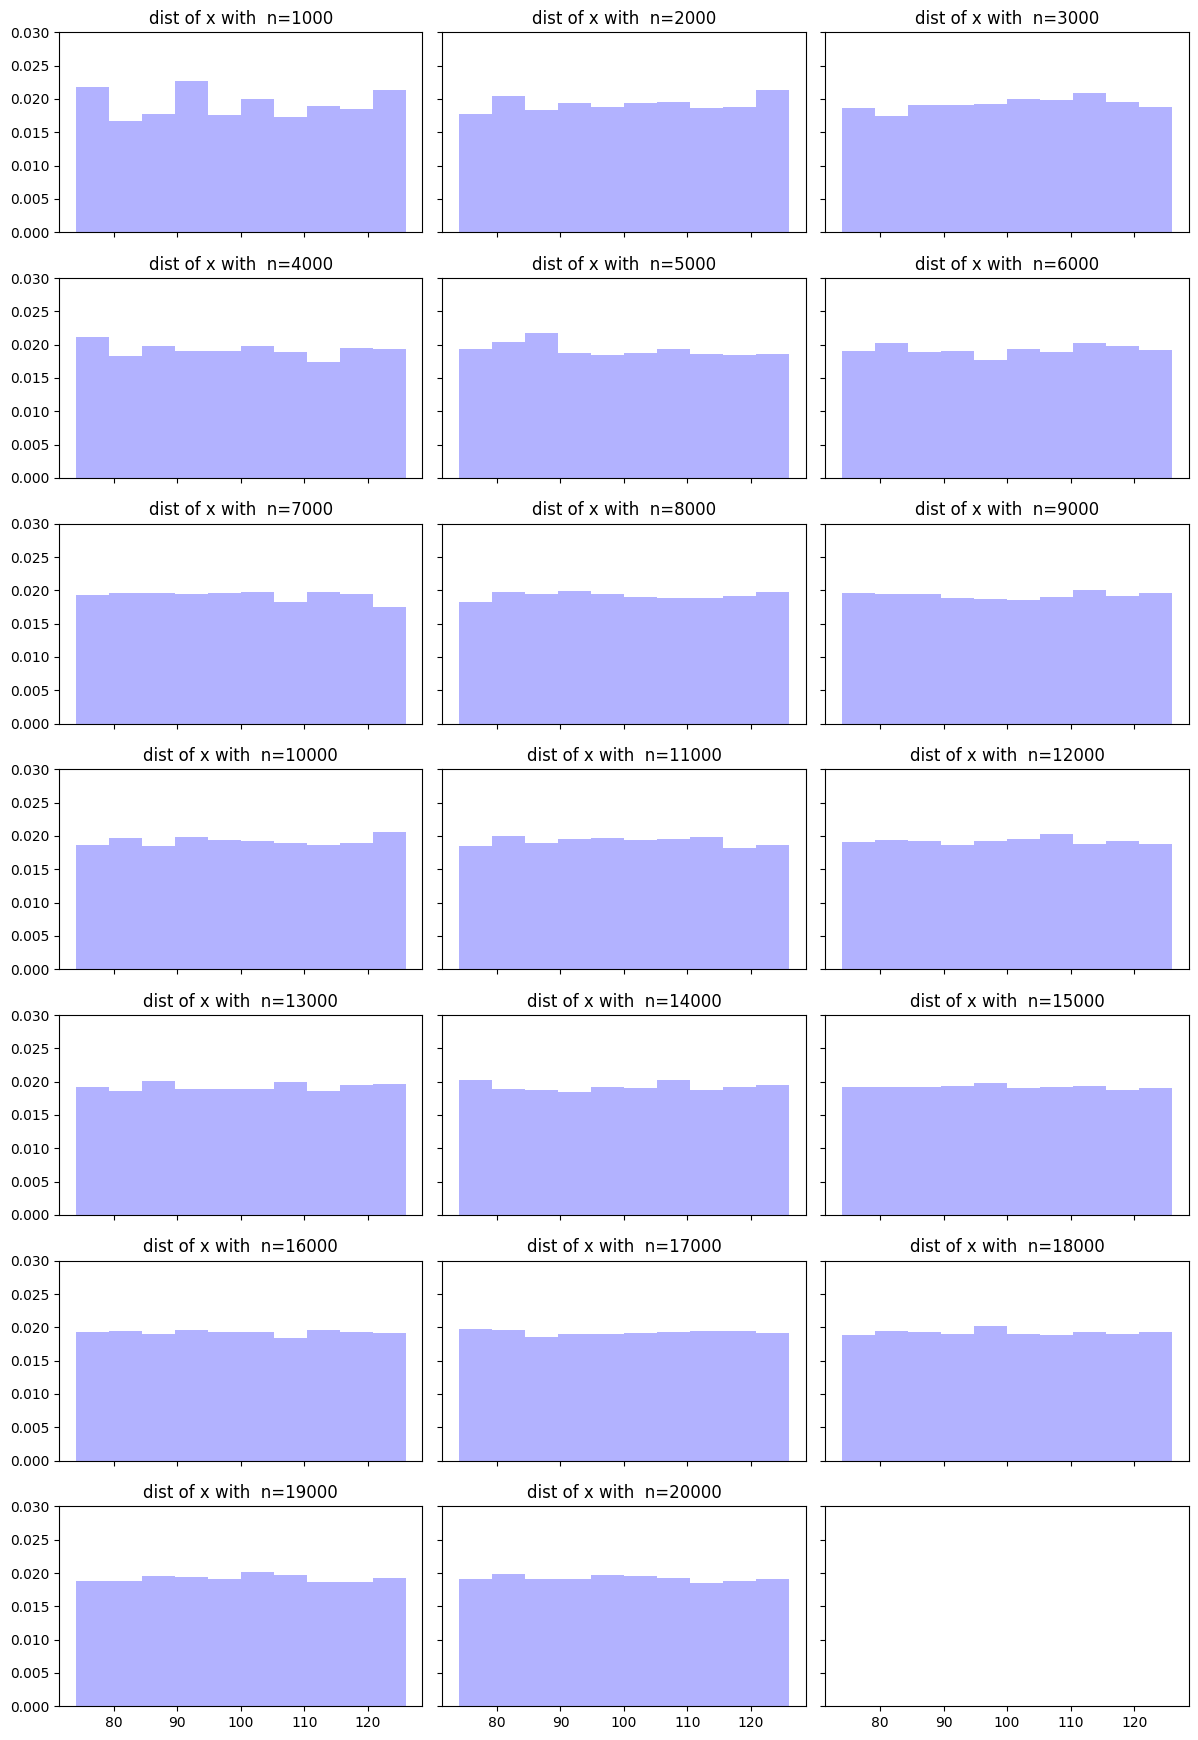

In [64]:
# 위 모의실험과 동일, 단, 각 표본 크기 당 1회의 표본 추출과 그 결과.
#fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), sharex=True)

fig, axes = plt.subplots(nrows= sub_r, ncols= sub_c,
                         figsize=(sub_c*box_w, sub_r*box_h),
                         sharex=True,
                         sharey=True
                         )
axes = axes.flatten()
for sub_i, k in enumerate( smpls ):
    n_smpl = k
    ax = axes[sub_i]
    #x = rng.normal(loc=mu, scale=sig, size=n_smpl)  # obs tbg
    x = rng.uniform(x_beg, x_end, n_smpl)
    ax.hist(x, color="blue", density='True', alpha=0.3)
    ax.set_title(f'dist of x with  n={k}') # n_smpl 별 서브플롯
    ax.set_ylim(0, 0.03) #plt.show()

plt.tight_layout()
plt.show()
